# 36118 AT1: How Skilled Migration Is Framed in Public Submissions

**Research question:** Which expected-benefit, risk, and policy-condition themes recur across the supplied submissions, and how consistently do those themes co-occur?

This notebook develops a reproducible, corpus-wide baseline for the 2026 AT1. It audits PDF extraction, applies an explicit theme dictionary, compares document prevalence with length-normalised mention rates, and checks theme co-occurrence. Dictionary matches indicate that a topic is discussed; they do **not** reveal whether the submitter supports or opposes a policy.

## 1. Corpus and analytical design

The supplied corpus contains public submissions to the Australian parliamentary inquiry into the value of skilled migration. PDF extraction quality varies, so the first analytical decision is to account for every file and flag documents that may require OCR. The main analysis uses transparent phrase patterns rather than an opaque topic model. This makes each measurement traceable and leaves room for manual validation in the final report.

In [1]:
import logging
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pypdf import PdfReader

RANDOM_SEED = 42
EXPECTED_PDF_COUNT = 143
MIN_EXTRACTED_CHARACTERS = 500
FIGURE_SIZE = (9, 5)
DATA_RELATIVE_PATH = Path(
    "data/submissions-skilled-migration/submissions_Skilledmigration"
)

THEME_PATTERNS = {
    "Economic contribution": [
        r"productivit", r"economic growth", r"innovation",
        r"investment", r"tax revenue",
    ],
    "Skills and essential services": [
        r"skills? shortage", r"critical skill", r"health(?:care)?",
        r"education", r"essential service",
    ],
    "Regional development": [
        r"regional australia", r"regional communit", r"rural",
        r"remote area",
    ],
    "Worker protection and fairness": [
        r"exploit", r"wage theft", r"worker rights?",
        r"labour standards?", r"fair work",
    ],
    "Permanent pathways and retention": [
        r"permanent residen", r"pathway.*permanen", r"retention",
        r"citizenship",
    ],
    "Recognition and visa processing": [
        r"skills? recognition", r"qualification recognition",
        r"processing time", r"visa processing", r"points test",
    ],
    "Housing and infrastructure pressure": [
        r"housing", r"infrastructure", r"cost of living",
        r"population pressure",
    ],
}

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="viridis")
logging.getLogger("pypdf").setLevel(logging.ERROR)

Matplotlib is building the font cache; this may take a moment.


### 1.1 Reproducible path discovery and extraction

In [2]:
def find_project_root(start: Path, data_path: Path) -> Path:
    """Find the AT1 directory without relying on a personal absolute path.

    Args:
        start: Directory from which to begin searching.
        data_path: Expected data location relative to the AT1 directory.

    Returns:
        The first parent directory containing the expected dataset.

    Raises:
        FileNotFoundError: If the dataset cannot be located.
    """
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / data_path).is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find {data_path}. Run the notebook inside the AT1 folder."
    )


def submission_sort_key(path: Path) -> tuple[int, str]:
    """Create a stable numeric key while preserving source filenames."""
    match = re.search(r"sub(\d+)", path.stem, flags=re.IGNORECASE)
    number = int(match.group(1)) if match else 10**9
    return number, path.stem.lower()


def extract_pdf(path: Path) -> dict[str, object]:
    """Extract one PDF and retain quality information.

    Args:
        path: PDF to process.

    Returns:
        A record containing identifiers, text, counts, and any error.
    """
    try:
        reader = PdfReader(path)
        page_text = [page.extract_text() or "" for page in reader.pages]
        text = "\n".join(page_text)
        return {
            "submission_id": path.stem,
            "filename": path.name,
            "page_count": len(reader.pages),
            "text": text,
            "extraction_error": None,
        }
    except Exception as exc:  # Continue the audit if one source is malformed.
        return {
            "submission_id": path.stem,
            "filename": path.name,
            "page_count": 0,
            "text": "",
            "extraction_error": f"{type(exc).__name__}: {exc}",
        }


PROJECT_ROOT = find_project_root(Path.cwd(), DATA_RELATIVE_PATH)
DATA_DIR = PROJECT_ROOT / DATA_RELATIVE_PATH
pdf_paths = sorted(DATA_DIR.glob("*.pdf"), key=submission_sort_key)

assert len(pdf_paths) == EXPECTED_PDF_COUNT, (
    f"Expected {EXPECTED_PDF_COUNT} PDFs, found {len(pdf_paths)} in {DATA_DIR}"
)

documents = pd.DataFrame(extract_pdf(path) for path in pdf_paths)
documents["character_count"] = documents["text"].str.len()
documents["word_count"] = documents["text"].str.findall(
    r"[A-Za-z]+(?:'[A-Za-z]+)?"
).str.len()
documents["needs_manual_review"] = (
    documents["character_count"] < MIN_EXTRACTED_CHARACTERS
)

print(f"AT1 root: {PROJECT_ROOT}")
print(f"PDFs accounted for: {len(documents)}")
print(f"Pages extracted: {documents['page_count'].sum():,}")
print(f"Extraction errors: {documents['extraction_error'].notna().sum()}")

AT1 root: /Users/tuannm3812/Documents/GitHub/1. Study/uts-mdsi/llm-wiki/02-subjects/36118-applied-natural-language-processing/assignments/current-2026/at1
PDFs accounted for: 143
Pages extracted: 1,670
Extraction errors: 0


## 2. Extraction-quality audit

,page_count,character_count,word_count
count,143.0,143.0,143.0
mean,11.7,27226.4,3712.9
std,15.0,39699.4,5568.4
min,1.0,73.0,10.0
25%,4.0,8784.0,1199.5
50%,7.0,16340.0,2165.0
75%,12.0,28973.5,4014.0
max,121.0,295143.0,41656.0


,submission_id,filename,page_count,character_count,word_count,extraction_error
139,Sub141,Sub141.pdf,1,73,10,None
132,Sub134,Sub134.pdf,3,215,30,None
111,Sub110,Sub110.pdf,4,287,40,None
99,Sub098,Sub098.pdf,6,425,60,None


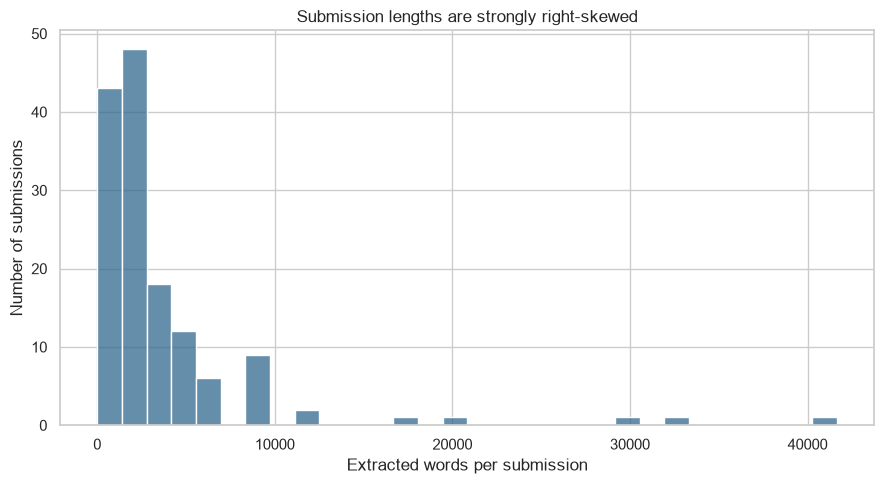

In [3]:
quality_summary = documents[[
    "page_count", "character_count", "word_count"
]].describe().round(1)
display(quality_summary)

review_columns = [
    "submission_id", "filename", "page_count", "character_count",
    "word_count", "extraction_error",
]
manual_review = documents.loc[
    documents["needs_manual_review"], review_columns
].sort_values("character_count")
display(manual_review)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
sns.histplot(documents["word_count"], bins=30, ax=ax, color="#31688e")
ax.set(
    title="Submission lengths are strongly right-skewed",
    xlabel="Extracted words per submission",
    ylabel="Number of submissions",
)
plt.tight_layout()
plt.show()

**Interpretation.** All 143 supplied files can be opened, but four contain fewer than 500 extracted characters and require manual inspection or OCR before their apparent lack of themes can be interpreted. Document lengths vary substantially, so raw corpus counts would allow long submissions to dominate. The main analysis therefore reports both the percentage of usable documents mentioning each theme and mentions per 10,000 words.

## 3. Transparent thematic measurement

The theme dictionary operationalises concepts suggested by the inquiry context: economic contribution, skills and services, regional development, worker protection, permanence, recognition and processing, and infrastructure pressure. Patterns deliberately use stems and small phrase families. They are inspectable but not exhaustive; polysemy and negation remain important limitations.

In [4]:
def normalise_text(text: str) -> str:
    """Lowercase text and collapse whitespace without removing negation."""
    return re.sub(r"\s+", " ", text.lower()).strip()


def count_theme_mentions(
    text: str,
    theme_patterns: dict[str, list[str]],
) -> dict[str, int]:
    """Count all configured pattern matches in one document.

    Args:
        text: Normalised document text.
        theme_patterns: Mapping from theme names to regex patterns.

    Returns:
        Match count for every theme.
    """
    return {
        theme: sum(len(re.findall(pattern, text)) for pattern in patterns)
        for theme, patterns in theme_patterns.items()
    }


usable = documents.loc[~documents["needs_manual_review"]].copy()
usable["normalised_text"] = usable["text"].map(normalise_text)
theme_counts = pd.DataFrame(
    usable["normalised_text"].map(
        lambda text: count_theme_mentions(text, THEME_PATTERNS)
    ).tolist(),
    index=usable.index,
)

total_words = usable["word_count"].sum()
theme_summary = pd.DataFrame({
    "documents_mentioning": (theme_counts > 0).sum(),
    "document_prevalence_pct": (theme_counts > 0).mean() * 100,
    "total_mentions": theme_counts.sum(),
    "mentions_per_10k_words": theme_counts.sum() / total_words * 10_000,
}).sort_values("document_prevalence_pct", ascending=False)

display(theme_summary.round(2))

,documents_mentioning,document_prevalence_pct,total_mentions,mentions_per_10k_words
Skills and essential services,130,93.53,2363,44.52
Economic contribution,123,88.49,1706,32.14
Housing and infrastructure pressure,107,76.98,1334,25.13
Permanent pathways and retention,104,74.82,756,14.24
Regional development,78,56.12,568,10.70
Recognition and visa processing,76,54.68,561,10.57
Worker protection and fairness,41,29.50,408,7.69


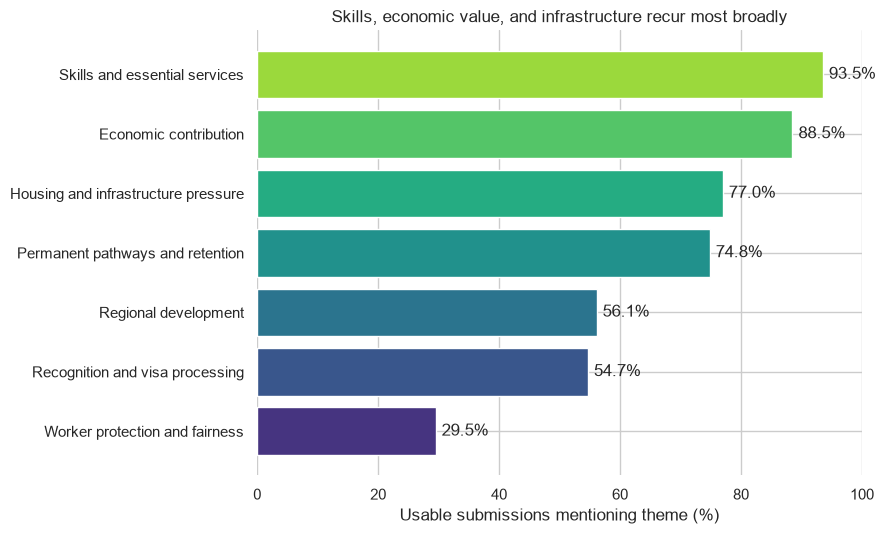

In [5]:
plot_data = theme_summary.sort_values("document_prevalence_pct")
fig, ax = plt.subplots(figsize=(9, 5.5))
colours = plt.colormaps["viridis"](
    np.linspace(0.15, 0.85, len(plot_data))
)
ax.barh(
    plot_data.index,
    plot_data["document_prevalence_pct"],
    color=colours,
)
ax.set(
    title="Skills, economic value, and infrastructure recur most broadly",
    xlabel="Usable submissions mentioning theme (%)",
    ylabel="",
    xlim=(0, 100),
)
for index, value in enumerate(plot_data["document_prevalence_pct"]):
    ax.text(value + 1, index, f"{value:.1f}%", va="center")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Interpretation.** Skills and essential services appear in 93.5% of usable submissions, followed by economic contribution (88.5%). Housing and infrastructure pressure is also broad (77.0%), showing that the corpus does not frame value only as labour-market benefit. Permanent pathways and retention occur in 74.8%, whereas explicit worker-protection language appears in 29.5%. These are measures of topical presence, not endorsement: a match may introduce a recommendation, criticism, or contextual example.

### 3.1 Theme co-occurrence

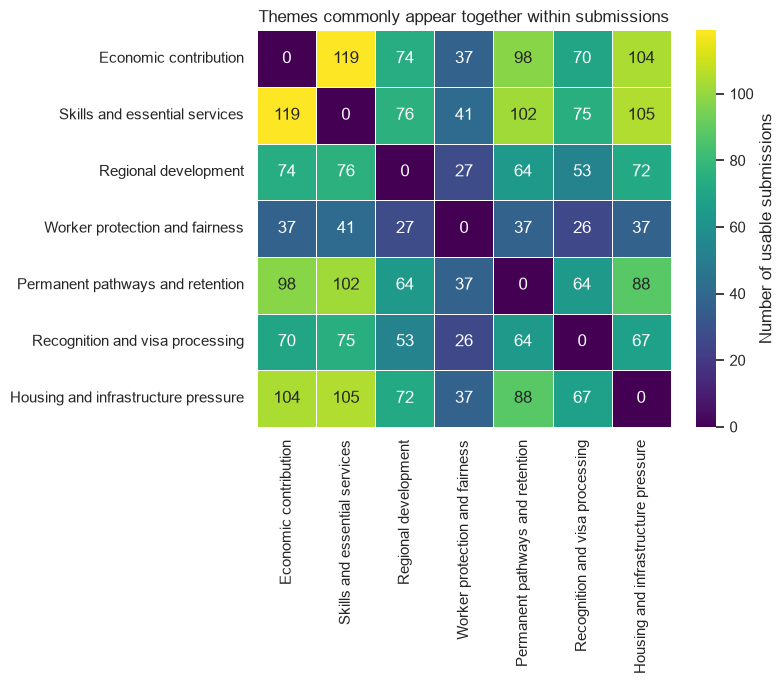

In [6]:
theme_presence = (theme_counts > 0).astype(int)
co_occurrence = theme_presence.T.dot(theme_presence)
np.fill_diagonal(co_occurrence.values, 0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    co_occurrence,
    cmap="viridis",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of usable submissions"},
    ax=ax,
)
ax.set_title("Themes commonly appear together within submissions")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Interpretation.** Co-occurrence prevents the analysis from forcing submissions into one-topic categories. The strongest intersections should be read as linked policy frames—for example, discussion of skills can coexist with economic value, service delivery, infrastructure capacity, or migration pathways. In the final report, the highest-frequency pairs should be checked against representative source passages to determine how the connection is argued.

## 4. Findings, limitations, and next steps

The baseline indicates that the value of skilled migration is framed most consistently through **skills and essential services** and **economic contribution**, but a large majority of documents also discuss **housing or infrastructure** and **permanent pathways**. This supports a multi-dimensional account: submissions connect workforce value to the conditions under which migrants and communities can sustain that value.

Important limitations remain. Four low-text PDFs may be scans and are excluded from theme prevalence; OCR could change the denominator and rare-theme counts. Regex patterns can miss synonyms, count boilerplate, or match a concept used negatively. The analysis does not yet distinguish submitter type, stance, or recommendation strength. Before final submission, manually inspect the flagged files, validate a stratified sample of matches and non-matches, review theme wording, and add verified excerpts. Submitter metadata should be added only when it can be reliably mapped to the supplied files.